# Avance 2 — Ingeniería de características y partición

**Bioactive AI** · Equipo 7 · Maestría en Inteligencia Artificial Aplicada (TC5035.10)

Convierte los SMILES en la matriz de características del modelo y construye la partición de evaluación. Parte de las decisiones del [Avance 1](01_EDA.html).

## Qué produce

1. **Descriptores 2D de RDKit** (217) más **Morgan/ECFP4** de 2048 bits.
2. **Sort & Slice** como alternativa libre de colisiones, con el vocabulario aprendido solo del entrenamiento.
3. Una **partición por andamio** verificada sin fuga, ni de andamio ni de estereoisómero.
4. El umbral de TPSA **rederivado sobre entrenamiento**, no tomado de la literatura.

## Decisiones que hereda del Avance 1

- **Entrenar con los grupos A+B** (4,679 compuestos). El grupo C tiene una distribución de clases distinta —50.0% BBB+ contra 73.0%—, así que mezclarlo introduce desplazamiento de distribución, no solo ruido.
- **Descartar las 2 filas con SMILES inválidos**, ambas del grupo C, que además cargan una inconsistencia nombre/estructura.
- **Scaffold split obligatorio.** Los andamios grandes tienen pureza de clase extrema: uno de 410 compuestos es 99.5% BBB+. Con partición aleatoria basta reconocer el andamio.

El código reutilizable vive en [`src/features/molecular.py`](https://github.com/AntonioVazquezMartinez/Bioactive-AI/blob/main/src/features/molecular.py) y [`src/data_prep/splits.py`](https://github.com/AntonioVazquezMartinez/Bioactive-AI/blob/main/src/data_prep/splits.py); este notebook los usa y muestra los resultados.

## 1. Preparación

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from features.molecular import (a_mol, descriptores_rdkit, limpiar_descriptores,
                                morgan_plegado, substructura_de_bit, SortAndSlice,
                                DESCRIPTORES_CLAVE)
from data_prep.splits import (andamio_murcko, esqueleto_conectividad,
                              scaffold_split, verificar_fuga, umbral_youden, SIN_ANDAMIO)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

## 2. Carga y filtro por confiabilidad

In [2]:
b3db = pd.read_csv(RAIZ / "data/external/b3db/B3DB_classification.tsv", sep="\t")
b3db["mol"] = b3db["SMILES"].map(a_mol)

invalidos = b3db["mol"].isna().sum()
b3db = b3db.dropna(subset=["mol"]).reset_index(drop=True)
b3db["y"] = (b3db["BBB+/BBB-"] == "BBB+").astype(int)

# decisión del Avance 1: entrenar con A+B
d = b3db[b3db["group"].isin(["A", "B"])].reset_index(drop=True)

print(f"B3DB completo      : {len(b3db) + invalidos} filas ({invalidos} SMILES inválidos descartados)")
print(f"Grupos A+B         : {len(d)} compuestos · {d['y'].mean()*100:.1f}% BBB+")
print(f"Grupo C (excluido) : {(b3db['group']=='C').sum()} · {b3db.loc[b3db['group']=='C','y'].mean()*100:.1f}% BBB+")
print(f"Grupo D (excluido) : {(b3db['group']=='D').sum()}")
print(f"\nrazón de desbalance en A+B: {(1-d['y'].mean())/d['y'].mean():.2f} negativos por positivo")

B3DB completo      : 7807 filas (2 SMILES inválidos descartados)
Grupos A+B         : 4679 compuestos · 73.0% BBB+
Grupo C (excluido) : 3075 · 50.0% BBB+
Grupo D (excluido) : 51

razón de desbalance en A+B: 0.37 negativos por positivo


## 3. Partición por andamio

In [3]:
d["andamio"] = [andamio_murcko(m) for m in d["mol"]]
d["esqueleto"] = [esqueleto_conectividad(m) for m in d["mol"]]

print(f"andamios de Murcko distintos : {d['andamio'].nunique()}")
print(f"esqueletos de conectividad   : {d['esqueleto'].nunique()}")
print(f"compuestos acíclicos         : {(d['andamio']==SIN_ANDAMIO).sum()}")
print(f"\ntamaño efectivo de muestra: {d['esqueleto'].nunique()} entidades, no {len(d)} filas")

andamios de Murcko distintos : 2243
esqueletos de conectividad   : 2887
compuestos acíclicos         : 212

tamaño efectivo de muestra: 2887 entidades, no 4679 filas


### 3.1 Dirección de la asignación

Un detalle que parece menor y no lo es: **los grupos grandes van a entrenamiento, no a prueba.**

Al construir la partición al revés —llenando primero la prueba con los andamios más frecuentes— resultaba un conjunto de evaluación con **45 andamios** contra 2,112 del entrenamiento, y el benceno solo ocupaba el 26% de la prueba. El desempeño medido ahí reflejaría esos pocos quimiotipos, no la capacidad del modelo.

La convención correcta, la de DeepChem, deja los andamios raros para evaluar: eso es lo que mide generalización a química nueva.

In [4]:
d["particion"] = scaffold_split(d, fraccion_prueba=0.2, fraccion_validacion=0.1,
                                semilla=SEMILLA, acíclicos_a="entrenamiento")

resumen = []
for p in ["entrenamiento", "validacion", "prueba"]:
    sub = d[d["particion"] == p]
    reales = sub[sub["andamio"] != SIN_ANDAMIO]["andamio"].value_counts()
    resumen.append({
        "partición": p,
        "n": len(sub),
        "% del total": round(len(sub)/len(d)*100, 1),
        "andamios": sub["andamio"].nunique(),
        "andamio mayor": int(reales.iloc[0]) if len(reales) else 0,
        "% que ocupa": round(reales.iloc[0]/len(sub)*100, 1) if len(reales) else 0.0,
        "% BBB+": round(sub["y"].mean()*100, 1),
    })
pd.DataFrame(resumen).set_index("partición")

,n,% del total,andamios,andamio mayor,% que ocupa,% BBB+
partición,,,,,,
entrenamiento,3339,71.4,1064,236,7.1,70.5
validacion,447,9.6,333,2,0.4,79.6
prueba,893,19.1,846,2,0.2,79.1


### 3.2 Verificación de fuga

In [5]:
informe = verificar_fuga(d)
print(f"andamios que aparecen en más de una partición   : {informe['andamios_cruzados']}")
print(f"esqueletos que aparecen en más de una partición : {informe['esqueletos_cruzados']}")
print(f"\n>>> SIN FUGA: {informe['sin_fuga']}")
if not informe["sin_fuga"]:
    print("  ejemplos de andamios:", informe["ejemplos_andamios"])
    print("  ejemplos de esqueletos:", informe["ejemplos_esqueletos"])

andamios que aparecen en más de una partición   : 0
esqueletos que aparecen en más de una partición : 0

>>> SIN FUGA: True


Verificar el esqueleto de conectividad, y no solo el andamio, es lo que evita que los estereoisómeros de un mismo compuesto se separen entre particiones. El Avance 1 encontró que la morfina aparece ocho veces en B3DB.

**Sobre el desplazamiento de clases:** la prueba y la validación quedan más ricas en BBB+ que el entrenamiento. Eso es inherente al scaffold split —los andamios raros de este conjunto tienden a ser permeables— y **no se corrige**: ajustar la partición para balancear las clases debilitaría justamente lo que la hace una prueba exigente. Se reporta como característica de la evaluación.

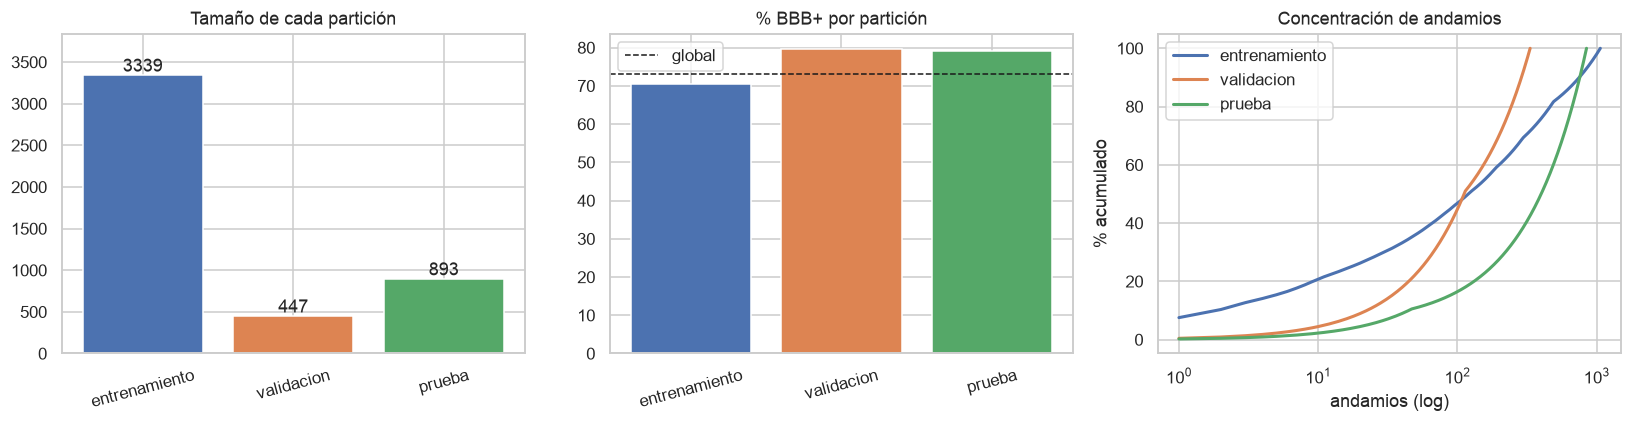

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

orden = ["entrenamiento", "validacion", "prueba"]
t = d["particion"].value_counts().reindex(orden)
axes[0].bar(range(3), t.values, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(orden, rotation=15)
for i, v in enumerate(t.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")
axes[0].set_title("Tamaño de cada partición"); axes[0].set_ylim(0, t.max()*1.15)

b = d.groupby("particion")["y"].mean().reindex(orden)*100
axes[1].bar(range(3), b.values, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].axhline(d["y"].mean()*100, ls="--", c="k", lw=1, label="global")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(orden, rotation=15)
axes[1].set_title("% BBB+ por partición"); axes[1].legend()

for p, c in zip(orden, ["#4C72B0", "#DD8452", "#55A868"]):
    sub = d[(d["particion"]==p) & (d["andamio"]!=SIN_ANDAMIO)]
    vc = sub["andamio"].value_counts()
    acum = vc.cumsum()/len(sub)*100
    axes[2].plot(range(1, len(vc)+1), acum.values, label=p, color=c, lw=2)
axes[2].set_xscale("log"); axes[2].set_xlabel("andamios (log)")
axes[2].set_ylabel("% acumulado"); axes[2].set_title("Concentración de andamios")
axes[2].legend()

plt.tight_layout(); plt.show()

La tercera gráfica es la que justifica la dirección de la asignación: la curva del entrenamiento sube rápido (tiene los andamios frecuentes) mientras las de prueba y validación son casi diagonales, o sea un andamio por compuesto. Esa diagonal es la señal de un conjunto de evaluación estructuralmente diverso.

## 4. Descriptores fisicoquímicos

In [7]:
import time
t0 = time.time()
desc = descriptores_rdkit(list(d["mol"]))
print(f"{desc.shape[1]} descriptores para {len(desc)} moléculas en {time.time()-t0:.1f}s")

# auditoría de calidad antes de usarlos
print("\nauditoría de columnas:")
desc_limpio, motivos = limpiar_descriptores(desc)

217 descriptores para 4679 moléculas en 19.9s

auditoría de columnas:
  descartadas por constantes: 5  (SMR_VSA8, SlogP_VSA9, fr_isocyan, fr_isothiocyan…)
  descartadas por con_nan: 8  (BCUT2D_MWHI, BCUT2D_MWLOW, BCUT2D_CHGHI, BCUT2D_CHGLO…)
  descartadas por no_finitas: 8  (BCUT2D_MWHI, BCUT2D_MWLOW, BCUT2D_CHGHI, BCUT2D_CHGLO…)
  descartadas por fuera_de_float32: 1  (Ipc)
  descriptores utilizables: 203 de 217


El criterio que importa en la práctica es el cuarto. **`Ipc`, el índice de contenido de información de RDKit, alcanza valores del orden de 1e41** en moléculas grandes: finitos en float64, pero por encima del máximo de float32 (~3.4e38). Random Forest convierte internamente a float32 y falla con *"Input X contains infinity or a value too large for dtype('float32')"*.

Es un desbordamiento conocido de ese descriptor y no lo detecta un chequeo de `isfinite`. Aquí costó una ejecución fallida encontrarlo.

In [8]:
# pares muy correlacionados: informativo, no se eliminan todavía
corr = desc_limpio.corr().abs()
triangulo = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
muy_corr = (triangulo > 0.95).sum().sum()
print(f"pares con |r| > 0.95: {muy_corr}")
print("\nlos descriptores clave para BBB siguen presentes:",
      [c for c in DESCRIPTORES_CLAVE if c in desc_limpio.columns])
print("descriptores utilizables:", desc_limpio.shape[1])

pares con |r| > 0.95: 123

los descriptores clave para BBB siguen presentes: ['TPSA', 'NumHDonors', 'MolLogP', 'MolWt', 'NumHAcceptors']
descriptores utilizables: 203


### 4.1 El umbral de TPSA, rederivado sobre entrenamiento

El Avance 1 mostró que el umbral óptimo de TPSA se mueve según el subconjunto: 66.6 Å² en el grupo A, 83.6 en A+B, 101.9 en el conjunto completo. La cifra de 66.8 Å² de la literatura no es una constante de la barrera.

Aquí se deriva **solo del entrenamiento**. Calcularlo sobre todo el conjunto filtraría información de la prueba, y ese umbral es el que después se usará para verificar las explicaciones del modelo.

In [9]:
d = pd.concat([d, desc_limpio[[c for c in DESCRIPTORES_CLAVE if c in desc_limpio.columns]]], axis=1)
tr = d["particion"] == "entrenamiento"

filas = []
for col, mayor_positivo in [("TPSA", False), ("NumHDonors", False), ("NumHAcceptors", False),
                            ("MolLogP", True), ("MolWt", False)]:
    if col not in d.columns:
        continue
    u_tr, auc_tr = umbral_youden(d.loc[tr, "y"].values, d.loc[tr, col].values, mayor_positivo)
    _, auc_pr = umbral_youden(d.loc[~tr, "y"].values, d.loc[~tr, col].values, mayor_positivo)
    filas.append({"descriptor": col, "umbral (entrenamiento)": round(u_tr, 1),
                  "AUC entrenamiento": round(auc_tr, 3), "AUC fuera de entrenamiento": round(auc_pr, 3)})
tabla = pd.DataFrame(filas).set_index("descriptor")
tabla["publicado (n=1058)"] = pd.Series({"TPSA": 0.746, "NumHDonors": 0.699,
                                         "NumHAcceptors": 0.673, "MolLogP": 0.617, "MolWt": 0.583})
tabla

,umbral (entrenamiento),AUC entrenamiento,AUC fuera de entrenamiento,publicado (n=1058)
descriptor,,,,
TPSA,107.0,0.865,0.798,0.746
NumHDonors,2.0,0.833,0.731,0.699
NumHAcceptors,4.0,0.824,0.722,0.673
MolLogP,1.5,0.766,0.591,0.617
MolWt,349.3,0.740,0.682,0.583


La caída del AUC entre entrenamiento y fuera de entrenamiento es la primera medida honesta de cuánto cuesta el scaffold split. Si un descriptor cae mucho, su poder discriminante dependía de los andamios frecuentes.

## 5. Fingerprints

In [10]:
mols = list(d["mol"])

t0 = time.time()
X_morgan = morgan_plegado(mols, radio=2, n_bits=2048)     # radio=2 es ECFP4
print(f"Morgan/ECFP4 plegado : {X_morgan.shape} en {time.time()-t0:.1f}s")
print(f"  densidad             : {X_morgan.mean()*100:.2f}% de bits activos")
print(f"  bits activos por mol : mediana {np.median(X_morgan.sum(1)):.0f}, rango [{X_morgan.sum(1).min()}, {X_morgan.sum(1).max()}]")
print(f"  bits nunca activos   : {(X_morgan.sum(0)==0).sum()} de {X_morgan.shape[1]}")

Morgan/ECFP4 plegado : (4679, 2048) en 0.1s
  densidad             : 2.26% de bits activos
  bits activos por mol : mediana 46, rango [1, 142]
  bits nunca activos   : 0 de 2048


### 5.1 Sort & Slice: fingerprint libre de colisiones

El plegado por hash hace que substructuras químicamente distintas compartan bit, lo que corrompe la atribución por SHAP: el modelo se ve forzado a asignar un valor único a fragmentos con efectos opuestos.

Sort & Slice ordena las substructuras por frecuencia y conserva las más frecuentes, de modo que **cada columna corresponde a una sola substructura**. El vocabulario se aprende **solo del entrenamiento**.

Se prefiere sobre CF-MF, la alternativa más reciente, porque CF-MF se validó únicamente con particiones aleatorias —lo admiten sus autores—, su paquete está en estado alfa y su adopción es casi nula. Ver [`03-explicabilidad`](https://antoniovazquezmartinez.github.io/Bioactive-AI/contenido/referencias/03-explicabilidad.html).

In [11]:
mols_tr = list(d.loc[tr, "mol"])

t0 = time.time()
ss = SortAndSlice(radio=2, n_bits=2048).fit(mols_tr)
X_ss = ss.transform(mols)
print(f"Sort & Slice: {X_ss.shape} en {time.time()-t0:.1f}s")
print(f"  vocabulario aprendido  : {len(ss.vocabulario)} substructuras")
print(f"  cobertura entrenamiento: {ss.cobertura(mols_tr)*100:.1f}%")
print(f"  cobertura prueba       : {ss.cobertura(list(d.loc[d.particion=='prueba','mol']))*100:.1f}%")
print(f"  densidad               : {X_ss.mean()*100:.2f}%")

Sort & Slice: (4679, 2048) en 0.2s
  vocabulario aprendido  : 2048 substructuras


  cobertura entrenamiento: 85.0%
  cobertura prueba       : 70.1%
  densidad               : 1.86%


La diferencia de cobertura entre entrenamiento y prueba es un indicador directo de **dominio de aplicabilidad**: mide qué fracción de las substructuras de la prueba el vocabulario reconoce. Una caída grande anticipa que el modelo está extrapolando.

In [12]:
# comparación de tamaños de vocabulario, para elegir n_bits con datos
filas = []
for n in [512, 1024, 2048, 4096]:
    s = SortAndSlice(radio=2, n_bits=n).fit(mols_tr)
    filas.append({"n_bits": n,
                  "vocabulario": len(s.vocabulario),
                  "cobertura entrenamiento %": round(s.cobertura(mols_tr)*100, 1),
                  "cobertura prueba %": round(s.cobertura(list(d.loc[d.particion=='prueba','mol']))*100, 1)})
pd.DataFrame(filas).set_index("n_bits")

,vocabulario,cobertura entrenamiento %,cobertura prueba %
n_bits,,,
512,512,66.9,55.4
1024,1024,76.8,63.5
2048,2048,85.0,70.1
4096,4096,92.3,75.5


### 5.2 De bit a substructura: el mecanismo de explicabilidad

In [13]:
# se toma un compuesto del entrenamiento y se decodifican algunos de sus bits
i = int(d.index[tr][0])
mol = d.loc[i, "mol"]
activos = np.flatnonzero(X_morgan[d.index.get_loc(i)])

print(f"compuesto: {d.loc[i, 'compound_name']}  ({d.loc[i, 'BBB+/BBB-']})")
print(f"bits activos: {len(activos)}\n")
for bit in activos[:8]:
    print(f"  bit {bit:>4} -> {substructura_de_bit(mol, int(bit))}")

compuesto: moxalactam  (BBB-)
bits activos: 71

  bit    1 -> C
  bit   80 -> C
  bit  116 -> S
  bit  172 -> C=C(C)COC
  bit  186 -> nnn
  bit  232 -> CC(C)=C(C(=O)O)N(C)C
  bit  255 -> CC(N)=O
  bit  257 -> cnnnn


Esto es lo que hace verificable la explicabilidad: un bit con peso SHAP alto se traduce en un fragmento químico concreto y dibujable. Es la razón por la que el proyecto usa fingerprints en vez de embeddings densos.

## 6. Matriz final y guardado

In [14]:
from scipy import sparse

# los descriptores se guardan densos; los fingerprints, dispersos
meta = d[["NO.", "compound_name", "SMILES", "y", "group", "andamio", "esqueleto", "particion"]].copy()

SALIDA = RAIZ / "data" / "processed"
SALIDA.mkdir(parents=True, exist_ok=True)

meta.to_parquet(SALIDA / "b3db_ab_meta.parquet", index=False)
desc_limpio.to_parquet(SALIDA / "b3db_ab_descriptores.parquet", index=False)
sparse.save_npz(SALIDA / "b3db_ab_morgan2048.npz", sparse.csr_matrix(X_morgan))
sparse.save_npz(SALIDA / "b3db_ab_sortslice2048.npz", sparse.csr_matrix(X_ss))
np.save(SALIDA / "b3db_ab_sortslice_vocabulario.npy", np.array(ss.vocabulario, dtype=np.int64))

for f in sorted(SALIDA.iterdir()):
    print(f"  {f.name:42} {f.stat().st_size/1e6:7.2f} MB")
print(f"\nmatriz combinada: {len(meta)} filas x ({desc_limpio.shape[1]} descriptores + {X_morgan.shape[1]} bits Morgan)")

  .gitkeep                                      0.00 MB
  b3db_ab_descriptores.parquet                  1.86 MB
  b3db_ab_meta.parquet                          0.28 MB
  b3db_ab_morgan2048.npz                        0.24 MB
  b3db_ab_sortslice2048.npz                     0.16 MB
  b3db_ab_sortslice_vocabulario.npy             0.02 MB

matriz combinada: 4679 filas x (203 descriptores + 2048 bits Morgan)


El vocabulario de Sort & Slice se guarda aparte: sin él no se puede transformar un compuesto nuevo, ni interpretar qué substructura representa cada columna.

## 7. Prueba de humo del pipeline

Un modelo mínimo para confirmar que las características y la partición funcionan. **No es el modelo del Avance 3**: sin ajuste de hiperparámetros, sin balanceo, sin selección de variables. Sirve para detectar errores de plomería, no para reportar desempeño.

Las métricas son **MCC y AUPRC**, no exactitud ni AUROC solos, por el desbalance de 2.7 a 1.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import matthews_corrcoef, average_precision_score, roc_auc_score, balanced_accuracy_score

itr = (d["particion"] == "entrenamiento").values
ipr = (d["particion"] == "prueba").values
y = d["y"].values

conjuntos = {
    "descriptores": desc_limpio.values,
    "Morgan": X_morgan,
    "Sort & Slice": X_ss,
    "descriptores + Morgan": np.hstack([desc_limpio.values, X_morgan]),
}

filas = []
for nombre, X in conjuntos.items():
    for modelo, etiqueta in [
        (make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEMILLA)), "LogReg"),
        (RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEMILLA), "RF"),
    ]:
        modelo.fit(X[itr], y[itr])
        p = modelo.predict(X[ipr])
        s = modelo.predict_proba(X[ipr])[:, 1]
        filas.append({"características": nombre, "modelo": etiqueta,
                      "MCC": round(matthews_corrcoef(y[ipr], p), 3),
                      "AUPRC": round(average_precision_score(y[ipr], s), 3),
                      "AUROC": round(roc_auc_score(y[ipr], s), 3),
                      "exactitud balanceada": round(balanced_accuracy_score(y[ipr], p), 3)})
pd.DataFrame(filas).set_index(["características", "modelo"])

MCC  AUPRC  AUROC  exactitud balanceada
características       modelo                                           
descriptores          LogReg  0.282  0.894  0.725                 0.620
                      RF      0.325  0.940  0.820                 0.602
Morgan                LogReg  0.202  0.879  0.680                 0.599
                      RF      0.260  0.918  0.771                 0.564
Sort & Slice          LogReg  0.227  0.885  0.690                 0.606
                      RF      0.276  0.920  0.778                 0.582
descriptores + Morgan LogReg  0.255  0.881  0.686                 0.625
                      RF      0.341  0.935  0.816                 0.606

> **Cómo NO leer esta tabla.** Son números de una sola corrida, sin ajuste ni validación cruzada, sobre una prueba deliberadamente difícil. No se deben comparar con los 0.92 de AUROC del leaderboard de TDC, que usan otro conjunto y otra implementación del scaffold split. El Avance 3 hará la comparación con método.
>
> Lo único que confirma esta tabla es que el pipeline corre y que las características tienen señal.

## 8. Conclusiones del Avance 2

### 8.1 La partición funciona y no filtra

| Partición | n | Andamios | Andamio mayor | % BBB+ |
|---|---|---|---|---|
| entrenamiento | 3,339 | 1,064 | 7.1% | 70.5 |
| validación | 447 | 333 | 0.4% | 79.6 |
| prueba | 893 | **846** | 0.2% | 79.1 |

**Cero andamios y cero esqueletos cruzados.** La prueba tiene 846 andamios distintos en 893 compuestos: casi uno por molécula, que es exactamente lo que se busca en una evaluación de generalización estructural.

**La dirección de la asignación resultó ser el detalle crítico.** Construida al revés —prueba llena de andamios frecuentes— daba 45 andamios con el benceno ocupando el 26%. Habría producido un número de desempeño que reflejaba tres quimiotipos.

### 8.2 El tamaño efectivo baja otra vez

Ya filtrados a A+B, los 4,679 compuestos corresponden a **2,887 esqueletos de conectividad**. La redundancia por estereoisomería no desaparece al quedarse con los grupos confiables.

Al reportar el tamaño del conjunto de entrenamiento hay que decir ambas cifras.

### 8.3 `Ipc` desborda float32

De los 217 descriptores quedan **203 utilizables**. El descarte que importa es `Ipc`, el índice de contenido de información: alcanza ~1e41, finito en float64 pero por encima del máximo de float32, y Random Forest convierte internamente. **Un chequeo de `isfinite` no lo detecta.** Costó una ejecución fallida encontrarlo, y ahora está cubierto en `limpiar_descriptores`.

### 8.4 El umbral de TPSA se mueve otra vez, y es la tercera cifra distinta

| Medición | Umbral óptimo |
|---|---|
| Publicado (n=1,058, subconjunto con logBB) | 66.8 Å² |
| Avance 1, sobre A+B completo (n=4,679) | 83.6 Å² |
| **Aquí, solo entrenamiento (n=3,339)** | **107.0 Å²** |

Tres subconjuntos del mismo dataset, tres umbrales que difieren en 40 Å². **Esto cierra el argumento: el 66.8 Å² de la literatura no es una constante de la barrera hematoencefálica, es el óptimo de un subconjunto particular.**

Para verificar las explicaciones del modelo se usará el umbral derivado del entrenamiento, y en la tesis se reportará sobre qué subconjunto se midió cada cifra.

### 8.5 El costo del scaffold split, medido

La caída de AUC entre entrenamiento y fuera de entrenamiento:

| Descriptor | Entrenamiento | Fuera | Caída |
|---|---|---|---|
| TPSA | 0.865 | 0.798 | −0.067 |
| NumHDonors | 0.833 | 0.731 | −0.102 |
| NumHAcceptors | 0.824 | 0.722 | −0.102 |
| MolWt | 0.740 | 0.682 | −0.058 |
| **MolLogP** | 0.766 | **0.591** | **−0.175** |

**logP es el más frágil**: pierde 0.175 y queda cerca del azar. Su poder discriminante dependía de los andamios frecuentes. TPSA es el más robusto, lo que refuerza usarlo como criterio principal de verificación.

### 8.6 Sort & Slice da la primera señal de dominio de aplicabilidad

| n_bits | Cobertura entrenamiento | Cobertura prueba | Brecha |
|---|---|---|---|
| 512 | 66.9% | 55.4% | 11.5 |
| 1,024 | 76.8% | 63.5% | 13.3 |
| **2,048** | **85.0%** | **70.1%** | **14.9** |
| 4,096 | 92.3% | 75.5% | 16.8 |

**La brecha no se cierra al aumentar el vocabulario: crece.** Eso significa que el 30% de las substructuras de la prueba simplemente no existen en el entrenamiento — es extrapolación estructural, no ruido. Se elige 2,048 porque más allá el rendimiento marginal por columna cae y la brecha empeora.

Esta medida anticipa directamente el problema que el marco teórico advierte para la etapa 2: los productos naturales estarán aún más lejos del dominio de entrenamiento que estos andamios raros.

### 8.7 La prueba de humo, con una advertencia sobre AUPRC

| Características | Modelo | MCC | AUROC |
|---|---|---|---|
| descriptores | RF | 0.325 | 0.820 |
| **descriptores + Morgan** | **RF** | **0.341** | 0.816 |
| Sort & Slice | RF | 0.276 | 0.778 |
| Morgan | RF | 0.260 | 0.771 |

Los descriptores solos superan a Morgan solo (MCC 0.325 contra 0.260), consistente con lo que reportaba la literatura. Combinarlos mejora marginalmente.

> **Corrección metodológica pendiente.** Reporté AUPRC siguiendo la recomendación del marco teórico para datos desbalanceados, pero aquí **la clase positiva es la mayoritaria** (79% BBB+ en la prueba). El AUPRC de la clase positiva tiene línea base 0.79, así que los valores de 0.88–0.94 son mucho menos informativos de lo que parecen.
>
> El AUPRC debe calcularse sobre la **clase minoritaria (BBB−)**, cuya línea base es 0.21. El Avance 3 lo corrige. Los MCC de esta tabla sí son válidos.

### 8.8 Siguientes pasos

**Avance 3** (`03_Baseline.ipynb`):

1. AUPRC sobre la clase minoritaria, no la mayoritaria.
2. Ajuste de hiperparámetros por validación cruzada, usando la partición de validación.
3. Control de Y-randomization contra correlación por azar.
4. Modelo interpretable simple entrenado en paralelo, como control de las explicaciones.

**Tareas de datos:**

- Filtro PAINS antes de reportar cualquier candidato.
- Resolver los 154 nombres de Spielvogel a SMILES para validación externa.
- Revisar los esqueletos con etiquetas contradictorias entre estereoisómeros.